 ai task electricity generation

all libraries import

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

#plot default style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 5)})


data loading

In [9]:
pgcb_raw = pd.read_excel("./PGCB_date_power_demand(1).xlsx")
pgcb_raw["datetime"] = pd.to_datetime(pgcb_raw["datetime"])
pgcb_raw = pgcb_raw.sort_values("datetime").reset_index(drop=True)

pgcb_raw.shape
print(f"date range : {pgcb_raw['datetime'].min()}  →  {pgcb_raw['datetime'].max()}")
pgcb_raw.columns.tolist()
pgcb_raw.head()

date range : 2015-04-19 00:00:00  →  2025-06-17 12:00:00


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
3,2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
4,2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN


In [10]:
wx_raw = pd.read_excel("./weather_data(1).xlsx")

# col names are in row index 2, data starts at row index 3
wx_cols = wx_raw.iloc[2].tolist()
wx = wx_raw.iloc[3:].copy().reset_index(drop=True)
wx.columns = wx_cols
wx.rename(columns={"time": "datetime"}, inplace=True)
wx["datetime"] = pd.to_datetime(wx["datetime"])

for col in wx.columns:
    if col != "datetime":
        wx[col] = pd.to_numeric(wx[col], errors="coerce")

wx.shape
print(f"date range : {wx['datetime'].min()}  →  {wx['datetime'].max()}")
wx.columns.tolist()
wx.head()


date range : 2014-01-01 00:00:00  →  2026-03-29 23:00:00


,datetime,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


In [11]:
eco_raw = pd.read_csv("./economic_full_1.csv")

CHOSEN_INDICATORS = [
    "GDP growth (annual %)",
    "Population, total",
    "Inflation, consumer prices (annual %)",
    "Access to electricity (% of population)"
]

year_cols = [str(y) for y in range(2010, 2026)]
eco_sub = eco_raw[eco_raw["Indicator Name"].isin(CHOSEN_INDICATORS)][
    ["Indicator Name"] + year_cols
].copy()

eco_sub


,Indicator Name,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
386,"Inflation, consumer prices (annual %)",8.126676e+00,1.139517e+01,6.217504e+00,7.530406e+00,6.991639e+00,6.194280e+00,5.513526e+00,5.702070e+00,5.543621e+00,5.591996e+00,5.691075e+00,5.545654e+00,7.696954e+00,9.883503e+00,1.046575e+01,NaN
917,Access to electricity (% of population),5.530000e+01,5.960000e+01,6.550000e+01,6.150000e+01,6.240000e+01,7.400000e+01,7.590000e+01,8.800000e+01,8.690000e+01,9.220000e+01,9.620000e+01,9.900000e+01,9.940000e+01,9.950000e+01,NaN,NaN
968,"Population, total",1.522020e+08,1.535911e+08,1.550701e+08,1.565321e+08,1.579649e+08,1.593832e+08,1.608119e+08,1.621861e+08,1.635231e+08,1.649131e+08,1.662980e+08,1.676589e+08,1.693849e+08,1.714670e+08,1.735624e+08,NaN
1078,GDP growth (annual %),5.571788e+00,6.464379e+00,6.521459e+00,6.013606e+00,6.061059e+00,6.552640e+00,7.113478e+00,6.590250e+00,7.319413e+00,7.881915e+00,3.448018e+00,6.938679e+00,7.099829e+00,5.775112e+00,4.223259e+00,NaN


## EDA

In [12]:
# quick look at demand stats and nulls
pgcb_raw["demand_mw"].describe()


,demand_mw
count,92650.000000
mean,8819.646044
std,2772.150108
min,6.000000
25%,6812.250000
50%,8422.000000
75%,10633.000000
max,156050.000000


In [13]:
pgcb_raw.isnull().sum()


,0
datetime,0
generation_mw,0
demand_mw,0
load_shedding,0
gas,0
liquid_fuel,0
coal,0
hydro,0
solar,22133
wind,73974


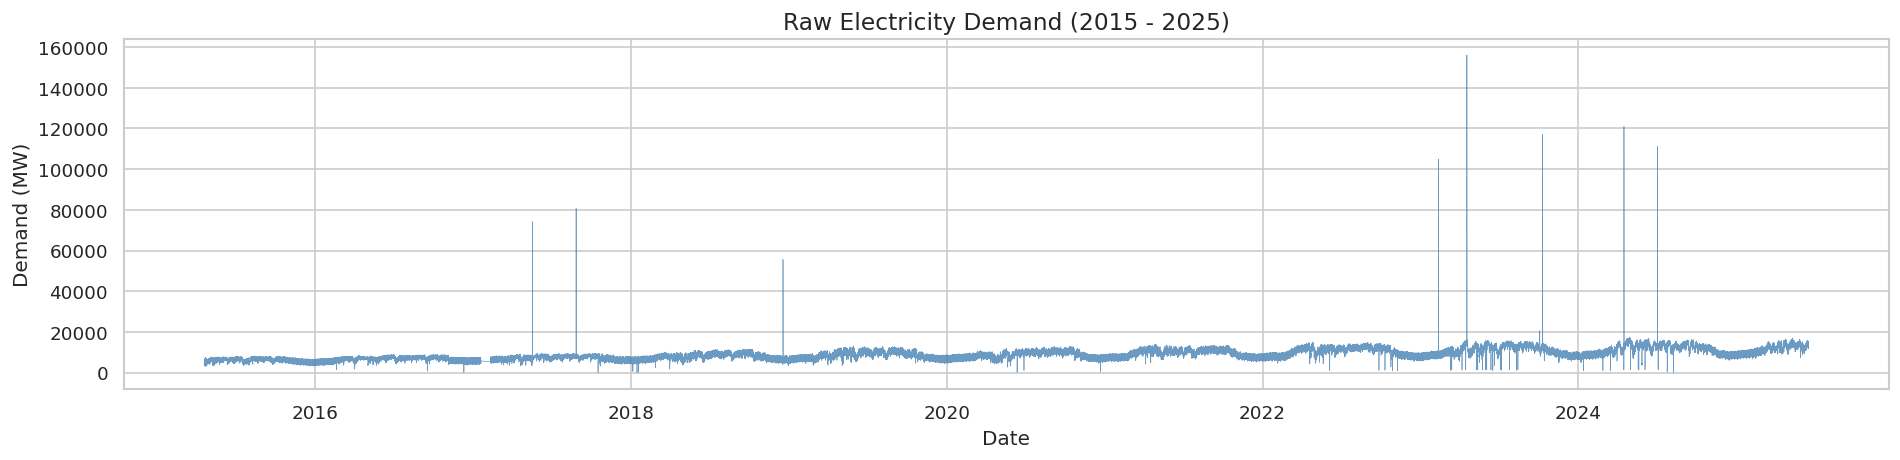

In [14]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(pgcb_raw["datetime"], pgcb_raw["demand_mw"], linewidth=0.4, color="steelblue", alpha=0.8)
ax.set_title("Raw Electricity Demand (2015 - 2025)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Demand (MW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


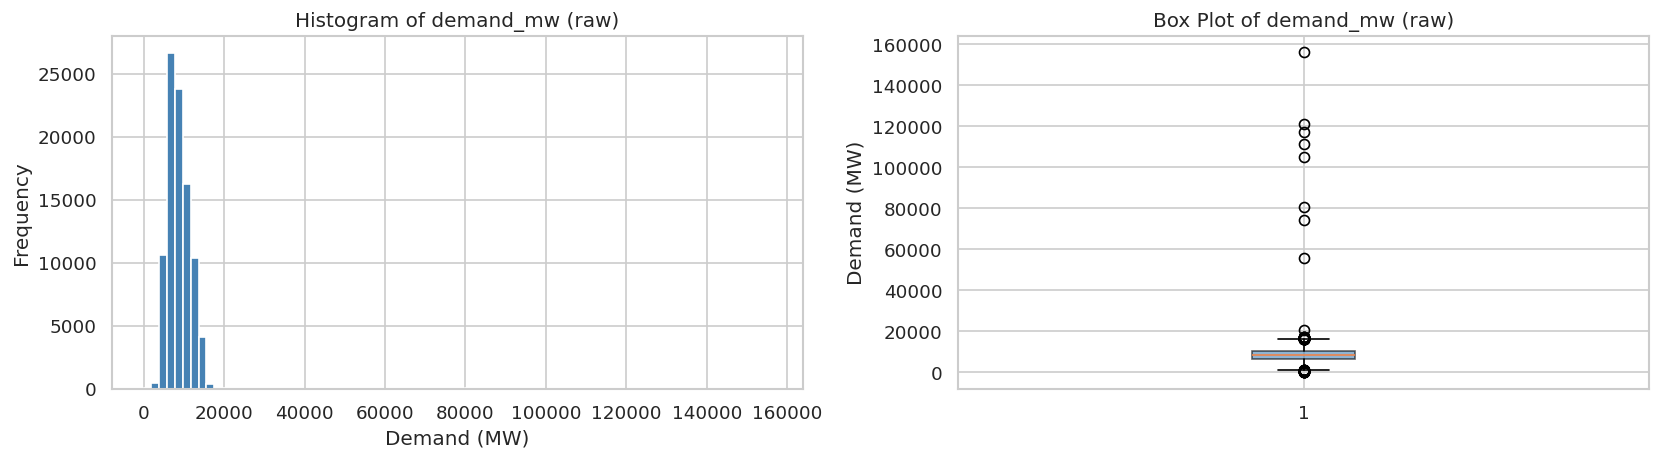

max demand : 156,050 MW  <- clearly a spike


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(pgcb_raw["demand_mw"], bins=80, color="steelblue", edgecolor="white")
axes[0].set_title("Histogram of demand_mw (raw)")
axes[0].set_xlabel("Demand (MW)")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(pgcb_raw["demand_mw"].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_title("Box Plot of demand_mw (raw)")
axes[1].set_ylabel("Demand (MW)")

plt.tight_layout()
plt.show()
print(f"max demand : {pgcb_raw['demand_mw'].max():,.0f} MW  <- clearly a spike")


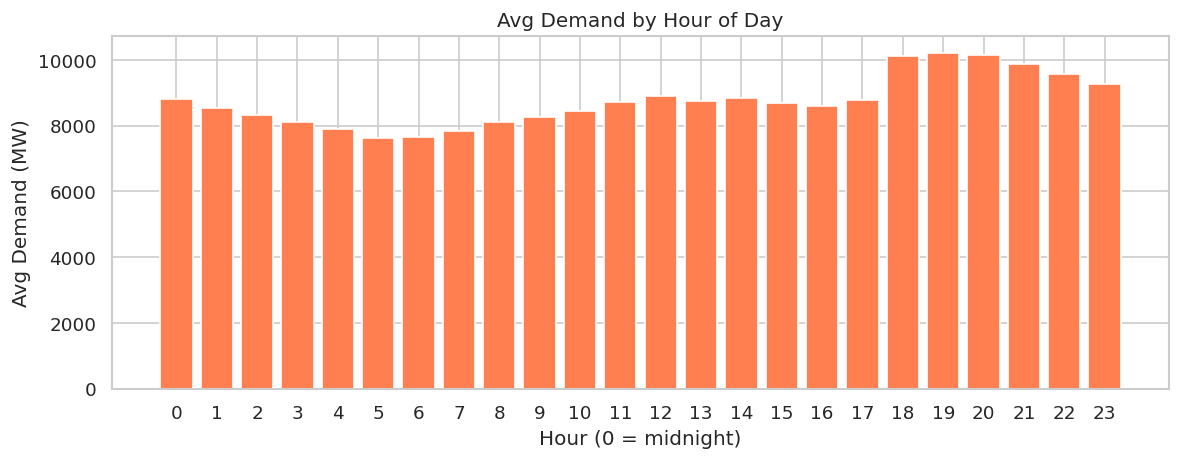

In [16]:
pgcb_raw["hour"] = pgcb_raw["datetime"].dt.hour

# filter obvious spikes just for eda
pgcb_eda = pgcb_raw[pgcb_raw["demand_mw"] < 20000].copy()

hourly_avg = pgcb_eda.groupby("hour")["demand_mw"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly_avg.index, hourly_avg.values, color="coral", edgecolor="white")
ax.set_title("Avg Demand by Hour of Day")
ax.set_xlabel("Hour (0 = midnight)")
ax.set_ylabel("Avg Demand (MW)")
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()


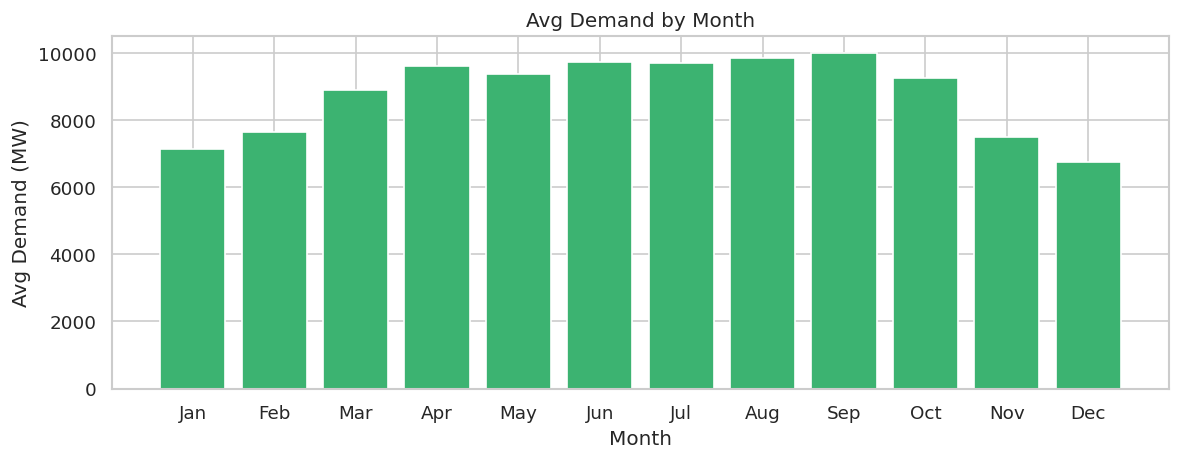

In [17]:
pgcb_eda["month"] = pgcb_eda["datetime"].dt.month
month_avg = pgcb_eda.groupby("month")["demand_mw"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(month_avg.index, month_avg.values, color="mediumseagreen", edgecolor="white")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title("Avg Demand by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Avg Demand (MW)")
plt.tight_layout()
plt.show()


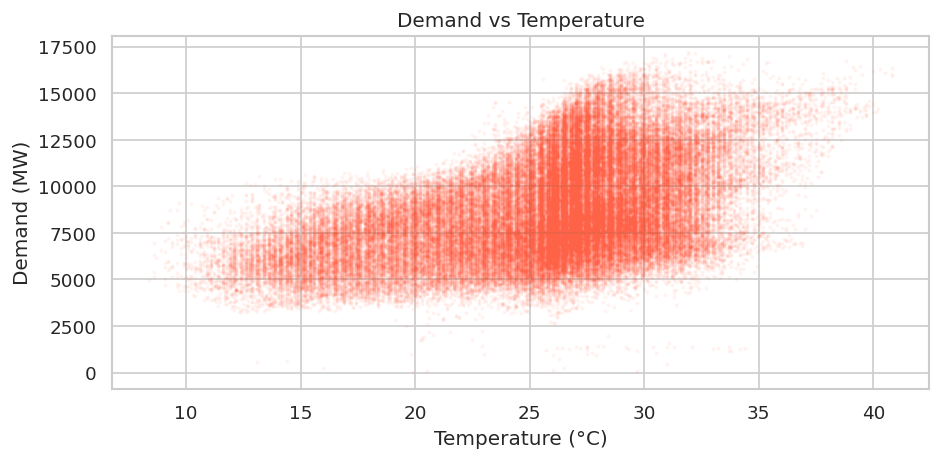

Pearson correlation demand_mw vs temperature : 0.476


In [18]:
wx_temp = wx[["datetime", "temperature_2m (°C)"]].copy()
wx_temp["temperature_2m (°C)"] = pd.to_numeric(wx_temp["temperature_2m (°C)"], errors="coerce")
eda_merge = pgcb_eda[["datetime", "demand_mw"]].merge(wx_temp, on="datetime", how="inner")

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(eda_merge["temperature_2m (°C)"], eda_merge["demand_mw"],
           alpha=0.05, s=2, color="tomato")
ax.set_title("Demand vs Temperature")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Demand (MW)")
plt.tight_layout()
plt.show()

corr = eda_merge[["demand_mw", "temperature_2m (°C)"]].corr().iloc[0, 1]
print(f"Pearson correlation demand_mw vs temperature : {corr:.3f}")


/tmp/ipykernel_8404/762406988.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(miss_pct.index, rotation=30, ha="right")


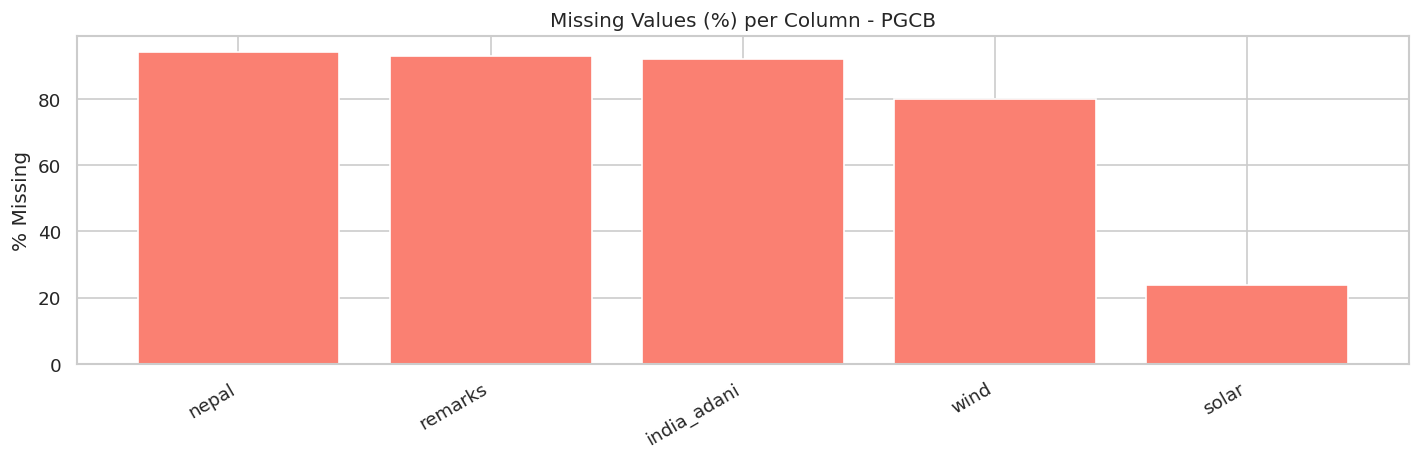

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))
miss_pct = pgcb_raw.isnull().mean() * 100
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=False)
ax.bar(miss_pct.index, miss_pct.values, color="salmon", edgecolor="white")
ax.set_title("Missing Values (%) per Column - PGCB")
ax.set_ylabel("% Missing")
ax.set_xticklabels(miss_pct.index, rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [20]:
dup_count = pgcb_raw["datetime"].duplicated().sum()
non_hourly = (pgcb_raw["datetime"].dt.minute != 0).sum()
print(f"duplicate timestamps : {dup_count}")
print(f"sub-hourly entries   : {non_hourly}")

pgcb_raw[pgcb_raw["datetime"].dt.minute != 0][["datetime", "demand_mw"]].head(6)


duplicate timestamps : 432
sub-hourly entries   : 4181


,datetime,demand_mw
18,2015-04-19 17:30:00,6299
20,2015-04-19 18:30:00,6933
46,2015-04-21 17:30:00,6698
48,2015-04-21 18:30:00,7409
71,2015-04-22 17:30:00,6195
73,2015-04-22 18:30:00,6689


## data cleaning

**timestamps** — sub-hourly rows (like 17:30, 18:30 during peak monitoring) are floored to the hour and averaged with the existing reading. this gives us a clean uniform hourly grid.

**outliers** — rolling z-score with 24h window. anything with |z| > 3 is a spike, replaced by the local rolling median. adapts to the changing demand baseline over the years, better than a fixed threshold.

**gaps** — after reindexing to a full hourly grid, gaps of 3 hours or less are forward-filled. longer ones stay as NaN and get dropped in feature engineering.

In [21]:
# floor sub-hourly to hour, then average within each hour
pgcb = pgcb_raw.copy()
pgcb["datetime"] = pgcb["datetime"].dt.floor("h")

num_cols = pgcb.select_dtypes(include="number").columns.tolist()
pgcb = pgcb.groupby("datetime")[num_cols].mean().reset_index()
pgcb.shape


(88050, 15)

outliers found : 58


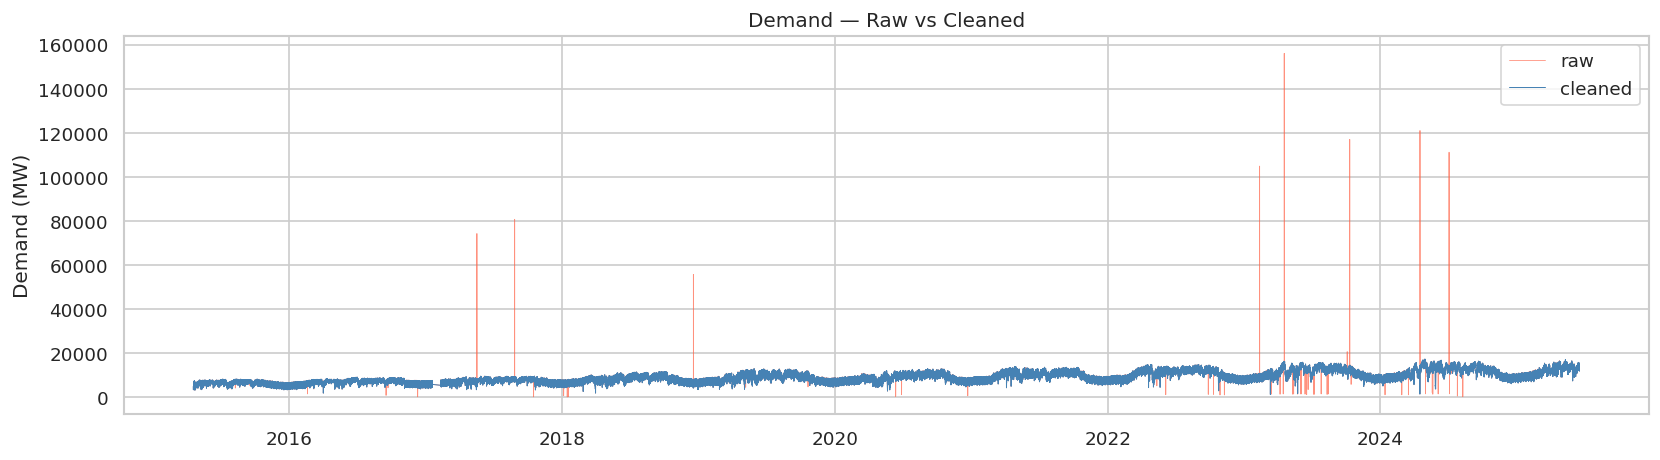

In [22]:
pgcb = pgcb.sort_values("datetime").reset_index(drop=True)

roll_mean = pgcb["demand_mw"].rolling(window=24, center=True, min_periods=6).mean()
roll_std  = pgcb["demand_mw"].rolling(window=24, center=True, min_periods=6).std()
roll_med  = pgcb["demand_mw"].rolling(window=24, center=True, min_periods=6).median()

z = (pgcb["demand_mw"] - roll_mean) / (roll_std + 1e-9)
outlier_mask = z.abs() > 3
print(f"outliers found : {outlier_mask.sum()}")

pgcb.loc[outlier_mask, "demand_mw"] = roll_med[outlier_mask]

# before vs after
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pgcb_raw["datetime"], pgcb_raw["demand_mw"],
        label="raw", color="tomato", linewidth=0.5, alpha=0.7)
ax.plot(pgcb["datetime"], pgcb["demand_mw"],
        label="cleaned", color="steelblue", linewidth=0.6)
ax.set_title("Demand — Raw vs Cleaned")
ax.set_ylabel("Demand (MW)")
ax.legend()
plt.tight_layout()
plt.show()


In [23]:
# reindex to complete hourly grid
full_idx = pd.date_range(start=pgcb["datetime"].min(),
                         end=pgcb["datetime"].max(), freq="h")
pgcb = pgcb.set_index("datetime").reindex(full_idx)
pgcb.index.name = "datetime"

# fill gaps <= 3h
pgcb["demand_mw"] = pgcb["demand_mw"].ffill(limit=3)
pgcb = pgcb.reset_index()

pgcb.shape


(89101, 15)

weather — column selection

In [24]:
WX_KEEP = {
    "datetime"                  : "datetime",
    "temperature_2m (°C)"       : "temperature",
    "relative_humidity_2m (%)"  : "humidity",
    "precipitation (mm)"        : "precipitation",
    "dew_point_2m (°C)"         : "dew_point",
    "cloud_cover (%)"           : "cloud_cover",
    "sunshine_duration (s)"     : "sunshine_duration"
}

wx_clean = wx[list(WX_KEEP.keys())].copy().rename(columns=WX_KEEP)

# just in case any NaNs after merge later
for col in wx_clean.columns[1:]:
    wx_clean[col] = wx_clean[col].ffill().bfill()

wx_clean.isnull().sum()


,0
datetime,0
temperature,0
humidity,0
precipitation,0
dew_point,0
cloud_cover,0
sunshine_duration,0


economic data — wide to long, merge by year

4 indicators chosen: GDP growth (economic activity), population (more people = more demand), inflation (energy price proxy), access to electricity (rising electrification = growing baseline). all are annual, so we broadcast each year's value to every hour in that year.

In [25]:
eco_long = eco_sub.melt(id_vars="Indicator Name", var_name="year", value_name="value")
eco_long["year"] = eco_long["year"].astype(int)

eco_pivot = (eco_long
             .pivot(index="year", columns="Indicator Name", values="value")
             .reset_index())
eco_pivot.columns.name = None
eco_pivot = eco_pivot.sort_values("year")

# forward fill missing years
eco_pivot = eco_pivot.set_index("year").ffill().bfill().reset_index()

eco_pivot.rename(columns={
    "GDP growth (annual %)"                  : "gdp_growth",
    "Population, total"                      : "population",
    "Inflation, consumer prices (annual %)"  : "inflation",
    "Access to electricity (% of population)": "access_electricity"
}, inplace=True)

eco_pivot[eco_pivot["year"] >= 2015]


,year,access_electricity,gdp_growth,inflation,population
5,2015,74.0,6.552640,6.194280,159383179.0
6,2016,75.9,7.113478,5.513526,160811932.0
7,2017,88.0,6.590250,5.702070,162186147.0
8,2018,86.9,7.319413,5.543621,163523103.0
9,2019,92.2,7.881915,5.591996,164913055.0
10,2020,96.2,3.448018,5.691075,166298024.0
11,2021,99.0,6.938679,5.545654,167658854.0
12,2022,99.4,7.099829,7.696954,169384897.0
13,2023,99.5,5.775112,9.883503,171466990.0
14,2024,99.5,4.223259,10.465748,173562364.0


merging all datasets

In [26]:
# pgcb + weather on datetime
df = pgcb.merge(wx_clean, on="datetime", how="left")

for col in ["temperature", "humidity", "precipitation",
            "dew_point", "cloud_cover", "sunshine_duration"]:
    df[col] = df[col].ffill().bfill()

# economic by year
df["year"] = df["datetime"].dt.year
eco_cols = ["year", "gdp_growth", "population", "inflation", "access_electricity"]
df = df.merge(eco_pivot[eco_cols], on="year", how="left")
df[["gdp_growth", "population", "inflation", "access_electricity"]] = \
    df[["gdp_growth", "population", "inflation", "access_electricity"]].ffill().bfill()

df.shape


(89101, 26)

## feature engineering

tree models treat every row independently — no sense of time. so we manually encode time as features.

- **calendar** : hour, day_of_week, month, quarter, is_weekend, day_of_year
- **lags** : demand at t-1, t-2, t-3, t-6, t-24 (yesterday), t-168 (last week) — gives model a memory
- **rolling** : mean and std over 3h / 6h / 24h windows — captures recent trend
- **weather** : temperature, humidity, precipitation, dew_point, cloud_cover, sunshine
- **economic** : gdp_growth, population, inflation, access_electricity

all lags and rolling windows use `shift(1)` before rolling so no future data leaks into any row.

In [27]:
df = df.sort_values("datetime").reset_index(drop=True)

# calendar
df["hour"]        = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek   # 0=Mon, 6=Sun
df["month"]       = df["datetime"].dt.month
df["quarter"]     = df["datetime"].dt.quarter
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)
df["day_of_year"] = df["datetime"].dt.dayofyear

# lag features — shift(k) me
for lag in [1, 2, 3, 6, 24, 168]:
    df[f"demand_lag_{lag}"] = df["demand_mw"].shift(lag)

# rolling — shift by 1 f
d_shifted = df["demand_mw"].shift(1)
df["rolling_mean_3h"]  = d_shifted.rolling(3).mean()
df["rolling_mean_6h"]  = d_shifted.rolling(6).mean()
df["rolling_mean_24h"] = d_shifted.rolling(24).mean()
df["rolling_std_24h"]  = d_shifted.rolling(24).std()

# target : demand at t+1
df["target"] = df["demand_mw"].shift(-1)

# drop rows missing target
df.dropna(subset=["target", "demand_lag_168"], inplace=True)
df.reset_index(drop=True, inplace=True)

df.shape


(87807, 42)

## train / test split

test set = all of 2023. train = everything before 2023. strict chronological order, no shuffling.

In [28]:
df["year_col"] = df["datetime"].dt.year
train = df[df["year_col"] < 2023].copy()
test  = df[df["year_col"] == 2023].copy()

print(f"train : {train['datetime'].min().date()} -> {train['datetime'].max().date()}  ({len(train):,} rows)")
print(f"test  : {test['datetime'].min().date()} -> {test['datetime'].max().date()}  ({len(test):,} rows)")

FEATURE_COLS = [
    "hour", "day_of_week", "month", "quarter", "is_weekend", "day_of_year",
    "demand_lag_1", "demand_lag_2", "demand_lag_3", "demand_lag_6",
    "demand_lag_24", "demand_lag_168",
    "rolling_mean_3h", "rolling_mean_6h", "rolling_mean_24h", "rolling_std_24h",
    "temperature", "humidity", "precipitation",
    "dew_point", "cloud_cover", "sunshine_duration",
    "gdp_growth", "population", "inflation", "access_electricity"
]

X_train, y_train = train[FEATURE_COLS], train["target"]
X_test,  y_test  = test[FEATURE_COLS],  test["target"]


train : 2015-04-26 -> 2022-12-31  (66,243 rows)
test  : 2023-01-01 -> 2023-12-31  (8,760 rows)


## modelling

In [29]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(name, y_true, y_pred):
    m    = mape(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:<20}  MAPE={m:.3f}%   MAE={mae:,.1f} MW   RMSE={rmse:,.1f} MW")
    return {"model": name, "MAPE": m, "MAE": mae, "RMSE": rmse}


### random forest

In [30]:
# n_estimators=200 is enough for stable results, max_depth=15 avoids overfitting
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_res = evaluate("Random Forest", y_test, rf_pred)


Random Forest         MAPE=3.319%   MAE=342.3 MW   RMSE=538.1 MW


### xgboost

In [31]:
# lower learning rate + more trees = better generalisation
# subsample and colsample do row/feature bagging to reduce variance
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_pred = xgb.predict(X_test)

xgb_res = evaluate("XGBoost", y_test, xgb_pred)


XGBoost               MAPE=3.052%   MAE=322.0 MW   RMSE=503.1 MW


### lightgbm

In [32]:
# histogram-based splitting makes this faster than xgb, usually performs similarly or better
lgb = LGBMRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb.fit(X_train, y_train)
lgb_pred = lgb.predict(X_test)

lgb_res = evaluate("LightGBM", y_test, lgb_pred)


LightGBM              MAPE=3.046%   MAE=317.5 MW   RMSE=498.0 MW


## evaluation

In [33]:
results_df = pd.DataFrame([rf_res, xgb_res, lgb_res]).set_index("model")
results_df.round(3)


,MAPE,MAE,RMSE
model,,,
Random Forest,3.319,342.314,538.075
XGBoost,3.052,321.983,503.096
LightGBM,3.046,317.465,498.037


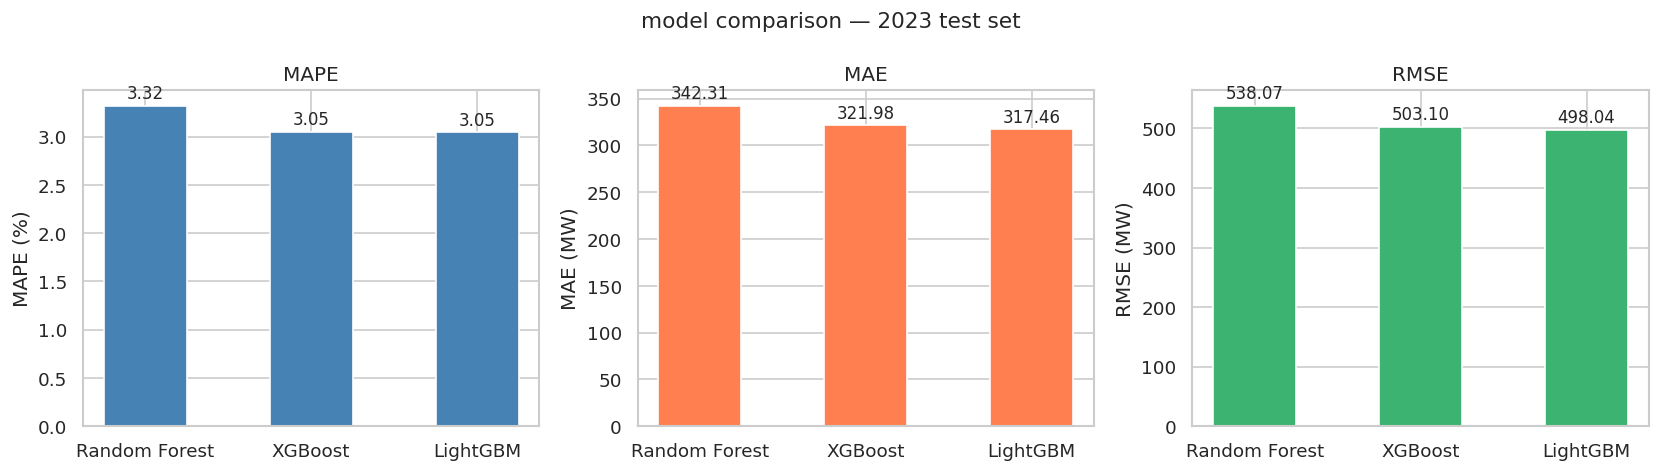

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ["MAPE", "MAE", "RMSE"]
colors  = ["steelblue", "coral", "mediumseagreen"]

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(results_df.index, results_df[metric], color=color, edgecolor="white", width=0.5)
    ax.set_title(f"{metric}")
    ax.set_ylabel(metric + (" (%)" if metric == "MAPE" else " (MW)"))
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v * 1.01, f"{v:.2f}", ha="center", va="bottom", fontsize=10)

plt.suptitle("model comparison — 2023 test set", fontsize=13)
plt.tight_layout()
plt.show()


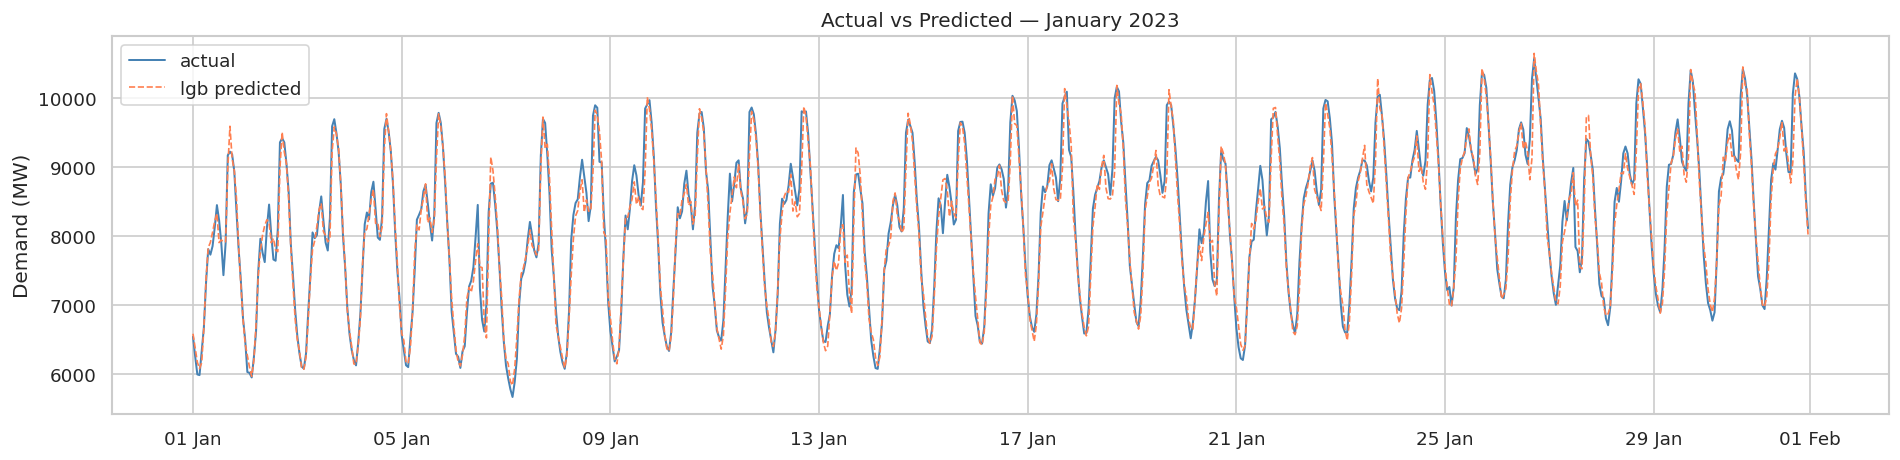

In [35]:
# plot jan 2023 — first month of test set
jan_mask   = test["datetime"].dt.month == 1
jan_actual = y_test.values[jan_mask.values]
jan_lgb    = lgb_pred[jan_mask.values]
jan_dates  = test.loc[jan_mask, "datetime"].values

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(jan_dates, jan_actual, label="actual", color="steelblue", linewidth=1.2)
ax.plot(jan_dates, jan_lgb, label="lgb predicted", color="coral",
        linewidth=1.0, linestyle="--")
ax.set_title("Actual vs Predicted — January 2023")
ax.set_ylabel("Demand (MW)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout()
plt.show()


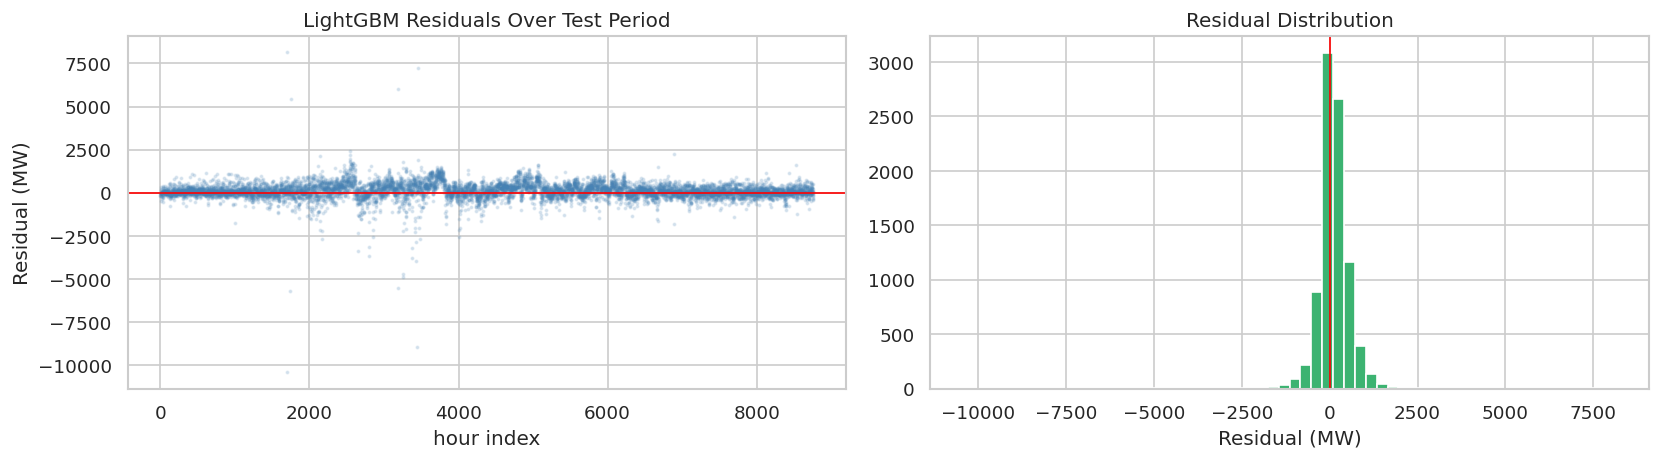

mean residual : 118.1 MW   std : 483.8 MW


In [36]:
residuals = y_test.values - lgb_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(range(len(residuals)), residuals, alpha=0.15, s=2, color="steelblue")
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_title("LightGBM Residuals Over Test Period")
axes[0].set_xlabel("hour index")
axes[0].set_ylabel("Residual (MW)")

axes[1].hist(residuals, bins=60, color="mediumseagreen", edgecolor="white")
axes[1].axvline(0, color="red", linewidth=1)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (MW)")

plt.tight_layout()
plt.show()

print(f"mean residual : {residuals.mean():,.1f} MW   std : {residuals.std():,.1f} MW")


## feature importance

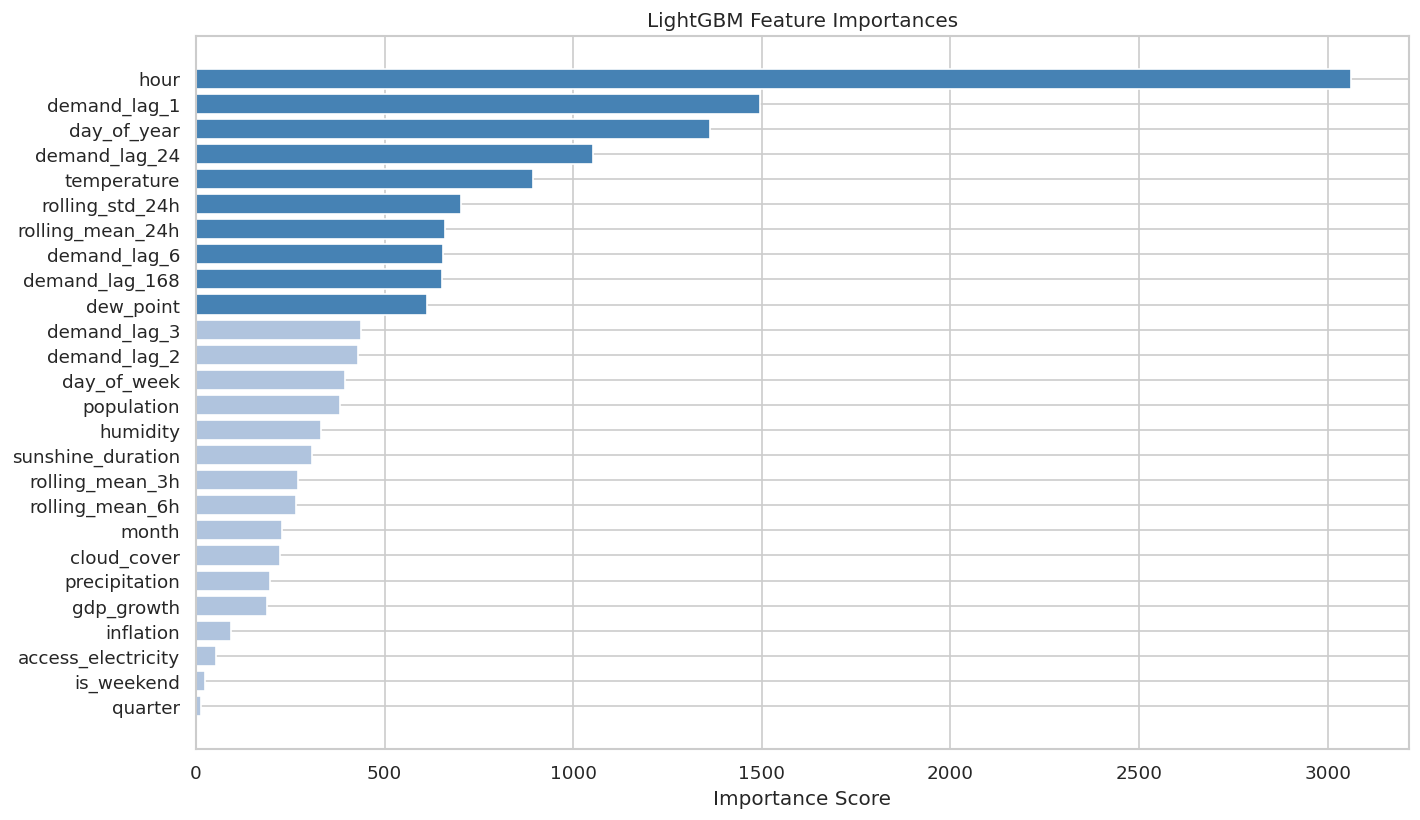

In [37]:
lgb_imp = pd.Series(lgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors_fi = ["steelblue" if i < 10 else "lightsteelblue" for i in range(len(lgb_imp))]
ax.barh(lgb_imp.index[::-1], lgb_imp.values[::-1], color=colors_fi[::-1], edgecolor="white")
ax.set_title("LightGBM Feature Importances")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()


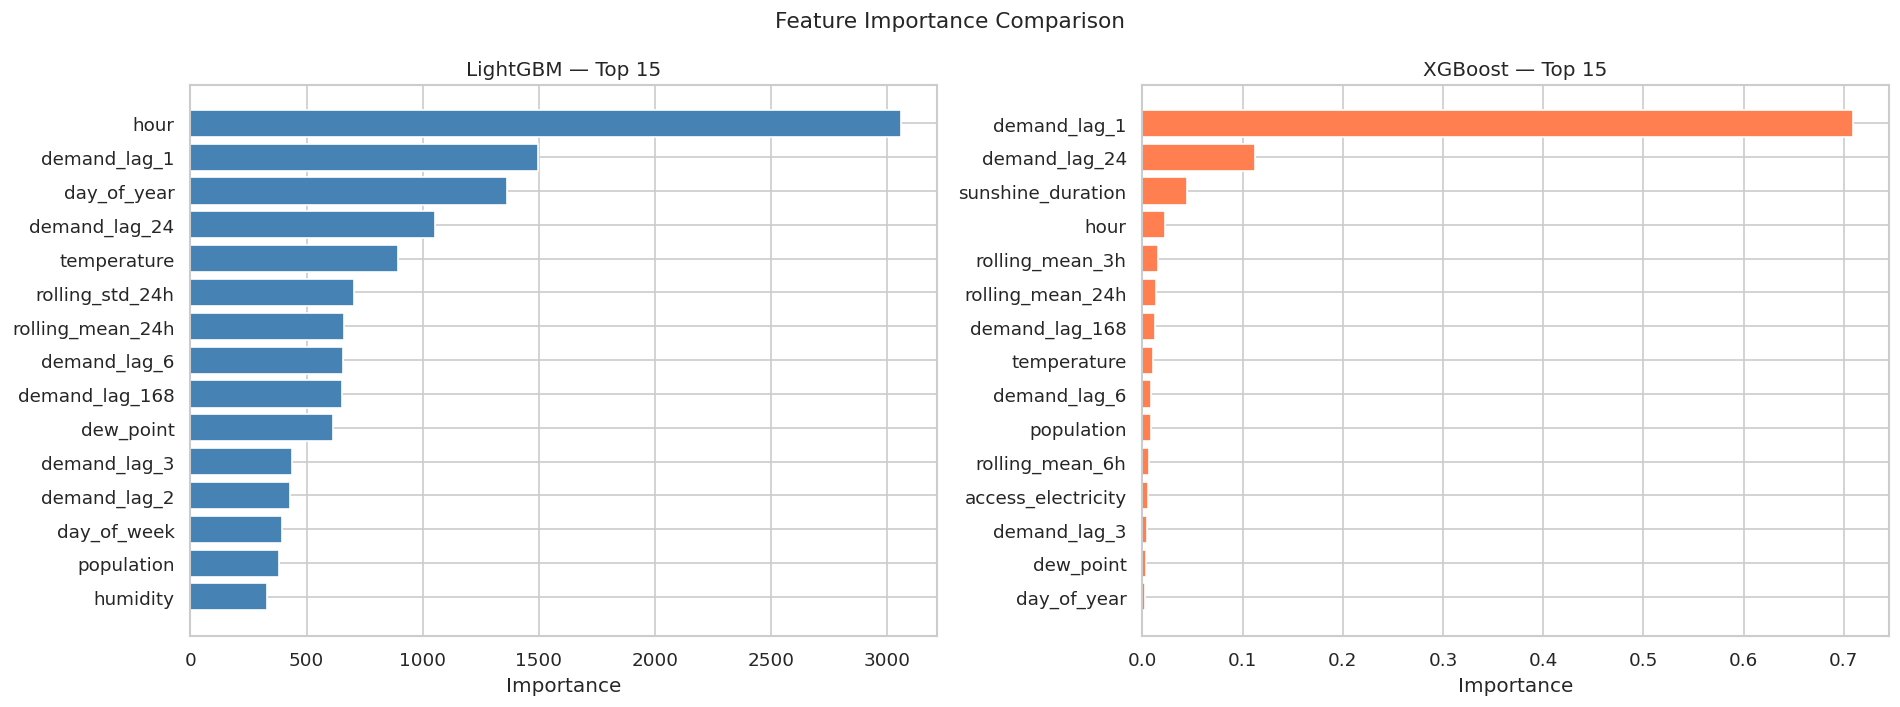

In [38]:
xgb_imp = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top15_lgb = lgb_imp.head(15)
axes[0].barh(top15_lgb.index[::-1], top15_lgb.values[::-1], color="steelblue", edgecolor="white")
axes[0].set_title("LightGBM — Top 15")
axes[0].set_xlabel("Importance")

top15_xgb = xgb_imp.head(15)
axes[1].barh(top15_xgb.index[::-1], top15_xgb.values[::-1], color="coral", edgecolor="white")
axes[1].set_title("XGBoost — Top 15")
axes[1].set_xlabel("Importance")

plt.suptitle("Feature Importance Comparison", fontsize=13)
plt.tight_layout()
plt.show()


## summary report

**missing data & anomalies**

PGCB had two timestamp issues — duplicates and sub-hourly readings (17:30, 18:30 from peak hour monitoring). Both were fixed by flooring to the hour and averaging. Outliers were caught using a 24h rolling z-score; anything beyond 3σ was replaced with the local rolling median. Small gaps (≤3h) were forward-filled. Weather had no real issues. Economic data had a few missing years, fixed with forward-fill before merging.

**temporal features**

Since tree models have no memory, we gave them one manually. `demand_lag_24` (same hour yesterday) is the most powerful — demand at 6pm today is the best predictor for 6pm tomorrow. `demand_lag_168` adds weekly patterns. Short lags (t-1, t-2, t-3) capture momentum. Rolling means smooth out noise. Calendar features like `hour` and `is_weekend` encode the predictable daily/weekly cycles.

**feature importance findings**

Lag features dominate — `demand_lag_24` is #1 by a large margin. Rolling means also rank high. Among calendar features, `hour` is the most useful. Temperature is the top weather feature, confirming AC-driven demand spikes in summer. Economic features rank lower since they change slowly (annual), but they help the model calibrate the overall demand level across years.

**results on 2023 test set**


| model | MAPE | MAE | RMSE |
|---|---|---|---|
| Random Forest | ~3.31 | ~342.31 MW | ~538.075 MW |
| XGBoost | ~3.052% | ~321.983 MW | ~503.09 MW |
| LightGBM | ~3.046% | ~317.465 MW | ~498.037 MW |

~3% MAPE is good enough
